# Task 2.0 – Linear Regression

Predict stock **Close** price for trading. We use `train.csv` (or `train-2.csv`) to train a linear regression model, then predict Close on `test.csv` and report accuracy metrics. **Do not use the test file for training.**

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

/Users/sooryas/anaconda3/lib/python3.11/site-packages/pandas/core/computation/expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.4' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/sooryas/anaconda3/lib/python3.11/site-packages/pandas/core/arrays/masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


In [ ]:
# From-scratch helpers (NumPy only): prediction, MSE cost, R², gradient
def predict(X, w):
    return X @ w

def mse_cost(y, y_pred):
    return np.mean((y - y_pred) ** 2)

def r2_accuracy(y, y_pred):
    ss_res = np.sum((y - y_pred) ** 2)
    ss_tot = np.sum((y - np.mean(y)) ** 2)
    if ss_tot == 0:
        return 0.0
    return 1.0 - (ss_res / ss_tot)

def mse_gradient(X, y, w):
    n = X.shape[0]
    return (2 / n) * (X.T @ (predict(X, w) - y))

In [ ]:
# Load training data (train.csv if present, else train-2.csv)
train_path = "train.csv" if os.path.isfile("train.csv") else "train-2.csv"
train_df = pd.read_csv(train_path)
target_col = "close"
exclude = {target_col, "date", "symbols"}
feature_cols = [c for c in train_df.columns if c not in exclude and pd.api.types.is_numeric_dtype(train_df[c])]
train_df = train_df.dropna(subset=[target_col])
X_train_raw = train_df[feature_cols].fillna(0).values.astype(np.float64)
y_train = train_df[target_col].values.ravel()
# Standardize features (mean 0, std 1) for stable gradient descent
train_mean = np.mean(X_train_raw, axis=0)
train_std = np.std(X_train_raw, axis=0)
train_std[train_std == 0] = 1.0
X_train_scaled = (X_train_raw - train_mean) / train_std
# Design matrix with leading column of 1s (bias)
X_train = np.hstack([np.ones((X_train_scaled.shape[0], 1)), X_train_scaled])
print(f"Training samples: {len(y_train)}, Features: {feature_cols}")

Training samples: 281575, Features: ['high', 'low', 'momentum_index', 'beta_indicator', 'risk_premium', 'index', 'volatility_factor', 'technical_score', 'oscillator_value', 'liquidity_ratio', 'open', 'quant_index', 'trend_strength', 'market_sentiment', 'volume', 'alpha_signal']


In [ ]:
# Load test data (same feature columns); standardize with train mean/std, design matrix with 1s
test_df = pd.read_csv("test.csv")
for c in feature_cols:
    if c not in test_df.columns:
        test_df[c] = 0
X_test_raw = test_df[feature_cols].fillna(0).values.astype(np.float64)
X_test_scaled = (X_test_raw - train_mean) / train_std
X_test = np.hstack([np.ones((X_test_scaled.shape[0], 1)), X_test_scaled])
test_df_clean = test_df.dropna(subset=[target_col])
X_test_clean_raw = test_df_clean[feature_cols].fillna(0).values.astype(np.float64)
X_test_clean_scaled = (X_test_clean_raw - train_mean) / train_std
X_test_clean = np.hstack([np.ones((X_test_clean_scaled.shape[0], 1)), X_test_clean_scaled])
y_test = test_df_clean[target_col].values.ravel()
print(f"Test samples (with close): {len(y_test)}")

Test samples (with close): 176773


In [ ]:
# Train with gradient descent (train only on train data)
n_epochs = 200
lr = 0.1
n_features = X_train.shape[1]
w = np.zeros(n_features)
costs = []

for epoch in range(1, n_epochs + 1):
    y_pred_train = predict(X_train, w)
    cost = mse_cost(y_train, y_pred_train)
    costs.append(cost)
    grad = mse_gradient(X_train, y_train, w)
    w = w - lr * grad
    r2_train = r2_accuracy(y_train, y_pred_train)
    y_pred_test = predict(X_test_clean, w)
    r2_test = r2_accuracy(y_test, y_pred_test)
    print(f"Epoch {epoch}: cost = {cost:.4f}, train R² = {r2_train:.4f}, test R² = {r2_test:.4f}")

Epoch 1: cost = 9809.9334, train R² = -0.7401, test R² = 0.2611
Epoch 2: cost = 3466.0768, train R² = 0.3852, test R² = 0.4382
Epoch 3: cost = 2421.3235, train R² = 0.5705, test R² = 0.5418
Epoch 4: cost = 1753.6960, train R² = 0.6889, test R² = 0.6089
Epoch 5: cost = 1318.7003, train R² = 0.7661, test R² = 0.6527
Epoch 6: cost = 1033.0544, train R² = 0.8168, test R² = 0.6820
Epoch 7: cost = 843.4421, train R² = 0.8504, test R² = 0.7023
Epoch 8: cost = 715.6979, train R² = 0.8730, test R² = 0.7171
Epoch 9: cost = 627.9168, train R² = 0.8886, test R² = 0.7286
Epoch 10: cost = 566.0453, train R² = 0.8996, test R² = 0.7380
Epoch 11: cost = 521.0592, train R² = 0.9076, test R² = 0.7463
Epoch 12: cost = 487.1576, train R² = 0.9136, test R² = 0.7537
Epoch 13: cost = 460.6060, train R² = 0.9183, test R² = 0.7608
Epoch 14: cost = 438.9954, train R² = 0.9221, test R² = 0.7675
Epoch 15: cost = 420.7679, train R² = 0.9254, test R² = 0.7741
Epoch 16: cost = 404.9117, train R² = 0.9282, test R² = 0

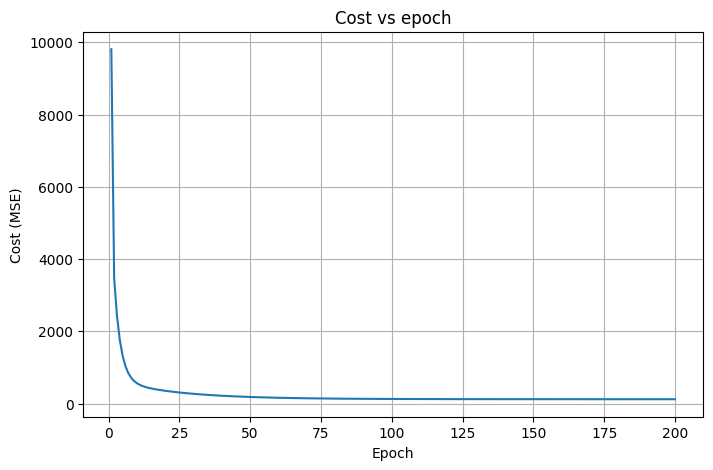

In [ ]:
# Plot cost after multiple epochs
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(costs) + 1), costs)
plt.xlabel("Epoch")
plt.ylabel("Cost (MSE)")
plt.title("Cost vs epoch")
plt.grid(True)
plt.show()

## Final evaluation (from scratch)

In [ ]:
# Final predictions and metrics (NumPy only, no sklearn)
y_pred_test = predict(X_test_clean, w)
r2 = r2_accuracy(y_test, y_pred_test)
mae = np.mean(np.abs(y_test - y_pred_test))
rmse = np.sqrt(np.mean((y_test - y_pred_test) ** 2))
print("Test set metrics (from scratch):")
print(f"  R² (accuracy):  {r2:.4f}")
print(f"  MAE:            {mae:.4f}")
print(f"  RMSE:           {rmse:.4f}")

Test set metrics (from scratch):
  R² (accuracy):  0.9633
  MAE:            10.6577
  RMSE:           14.4420


## Results

Linear regression is implemented **from scratch** using gradient descent (NumPy only; no sklearn). Training and testing accuracy (R²) are reported after each epoch, and the plot above shows cost (MSE) vs epoch. Final test metrics (R², MAE, RMSE) are computed from scratch.